In [1]:
import polars as pl
import plotly.express as px
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import LineCollection

import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pl.read_parquet("../data/processed/df_clean.parquet")
print(df.head())
print(df.shape)

shape: (5, 31)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ track_id ┆ race_date ┆ race_numb ┆ program_n ┆ … ┆ is_first_ ┆ distance_ ┆ cumulativ ┆ speed_kmh │
│ ---      ┆ ---       ┆ er        ┆ umber     ┆   ┆ obs       ┆ m         ┆ e_distanc ┆ ---       │
│ str      ┆ str       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ e_m       ┆ f64       │
│          ┆           ┆ i64       ┆ str       ┆   ┆ bool      ┆ f64       ┆ ---       ┆           │
│          ┆           ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆           │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ AQU      ┆ 2019-01-0 ┆ 1         ┆ 1         ┆ … ┆ true      ┆ 0.0       ┆ 0.0       ┆ null      │
│          ┆ 1         ┆           ┆           ┆   ┆           ┆           ┆           ┆           │
│ AQU      ┆ 2019-01-0 ┆ 1         ┆ 1         ┆ … ┆ false     ┆ 0.52915   ┆

In [3]:
df["distance_m"].describe()

statistic,value
str,f64
"""count""",5.065657e6
"""null_count""",0.0
"""mean""",4.618203
"""std""",0.747715
"""min""",0.0
"""25%""",4.426883
"""50%""",4.766893
"""75%""",5.018469
"""max""",243.22699


In [3]:
df["horse_pk"].unique().sort().head(10).to_list()

['AQU_2019-01-01_1_1',
 'AQU_2019-01-01_1_2',
 'AQU_2019-01-01_1_3',
 'AQU_2019-01-01_1_4',
 'AQU_2019-01-01_1_5',
 'AQU_2019-01-01_2_1',
 'AQU_2019-01-01_2_2',
 'AQU_2019-01-01_2_3',
 'AQU_2019-01-01_2_4',
 'AQU_2019-01-01_2_5']

In [4]:
pl.Config.set_tbl_rows(-1)  # Show all rows
df["distance_id"].value_counts().sort(by="count", descending=True)

distance_id,count
i64,u32
600,1181552
800,1128791
850,765069
700,580526
650,459907
900,402129
550,258302
1000,87140
1100,81691


In [5]:
# sample row with distance_id = 1600
df.filter(pl.col("distance_id") == 1600).head(1)

track_id,race_date,race_number,program_number,trakus_index,latitude,longitude,distance_id,course_type,track_condition,run_up_distance,race_type,purse,post_time,weight_carried,jockey,odds,position_at_finish,horse_pk,rid,horse_id,horse_name,win,time_seconds,prev_latitude,prev_longitude,prev_time_seconds,distance_meters,speed_kmh,race_progress,race_stage
str,str,i64,str,i64,f64,f64,i64,str,str,i64,str,f64,i64,i64,str,i64,i64,str,str,str,str,i8,f64,f64,f64,f64,f64,f64,f64,str
"""BEL""","""2019-06-07""",10,"""1""",1,40.716634,-73.721807,1600,"""Turf""","""FM """,152,"""STK""",400000.0,548,121,"""Ben Curtis""",1910,7,"""BEL_2019-06-07_10_1""","""BEL_2019-06-07_10""","""3286""","""Mootasadir (GB)""",0,0.25,null,null,null,0.0,null,0.001355,"""stage1"""


In [6]:
# horse_pk from a race with distance_id = 1600


RACE SUMMARY FOR HORSE: BEL_2019-06-07_10_1
Track: BEL
Total tracking points: 738
Race duration (trakus indices): 1 - 738
Total distance covered: 3362.72 meters
Average speed: 4.56 m/s (16.43 km/h)
Maximum speed: 5.40 m/s (19.44 km/h)


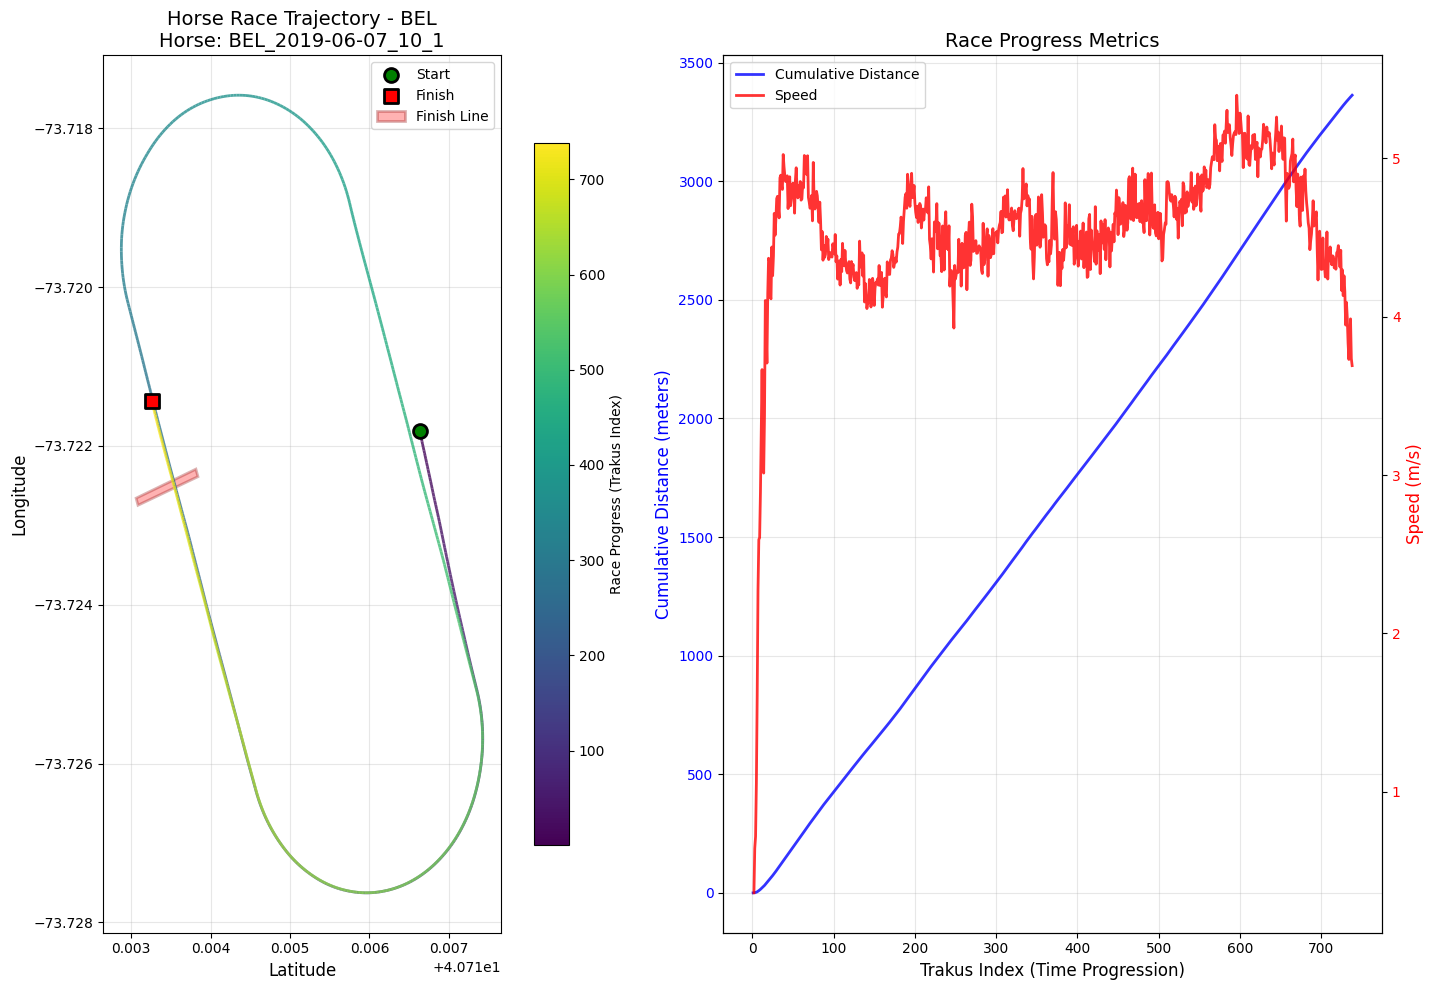

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import LineCollection

def visualize_horse_race_progress(df, horse_pk, race_id=None, figsize=(15, 10)):
    """
    Visualize a single horse's race progress using GPS coordinates.
    
    Args:
        df: Polars DataFrame with horse tracking data
        horse_pk: Unique horse identifier to visualize
        race_id: Optional race identifier for title
        figsize: Figure size tuple (width, height)
    """
    
    # Filter data for the specific horse
    horse_data = df.filter(pl.col("horse_pk") == horse_pk).sort("trakus_index")
    
    if horse_data.shape[0] == 0:
        print(f"No data found for horse_pk: {horse_pk}")
        return None, None
    
    # Convert to pandas for easier matplotlib integration
    horse_df = horse_data.to_pandas()
    
    # Extract coordinates and metadata
    latitudes = horse_df['latitude'].values
    longitudes = horse_df['longitude'].values
    trakus_indices = horse_df['trakus_index'].values
    track_id = horse_df['track_id'].iloc[0]
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: GPS Trajectory with Progress Coloring
    # Create a colormap based on race progress (trakus_index)
    colors = plt.cm.viridis(np.linspace(0, 1, len(trakus_indices)))
    
    # Create line segments for gradient coloring
    points = np.array([latitudes, longitudes]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Create line collection with gradient colors
    lc = LineCollection(segments, colors=colors[1:], linewidths=2, alpha=0.8)
    ax1.add_collection(lc)
    
    # Add start and finish markers
    ax1.scatter(latitudes[0], longitudes[0], c='green', s=100, marker='o', 
               label='Start', zorder=5, edgecolors='black', linewidths=2)
    ax1.scatter(latitudes[-1], longitudes[-1], c='red', s=100, marker='s', 
               label='Finish', zorder=5, edgecolors='black', linewidths=2)
    
    # Add finish line polygon if available
    finish_line_coords = get_finish_line_coords(track_id)
    if finish_line_coords:
        finish_polygon = MplPolygon(finish_line_coords, alpha=0.3, 
                                  facecolor='red', edgecolor='darkred', 
                                  linewidth=2, label='Finish Line')
        ax1.add_patch(finish_polygon)
    
    # Customize first subplot
    ax1.set_xlabel('Latitude', fontsize=12)
    ax1.set_ylabel('Longitude', fontsize=12)
    ax1.set_title(f'Horse Race Trajectory - {track_id}\nHorse: {horse_pk}', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_aspect('equal')
    
    # Add colorbar for race progress
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                              norm=plt.Normalize(vmin=trakus_indices.min(), 
                                               vmax=trakus_indices.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
    cbar.set_label('Race Progress (Trakus Index)', fontsize=10)
    
    # Plot 2: Race Progress Metrics
    # Calculate distance from start
    distances = calculate_cumulative_distance(latitudes, longitudes)
    
    # Create dual y-axis plot
    ax2_twin = ax2.twinx()
    
    # Plot distance progression
    line1 = ax2.plot(trakus_indices, distances, 'b-', linewidth=2, 
                     label='Cumulative Distance', alpha=0.8)
    ax2.set_xlabel('Trakus Index (Time Progression)', fontsize=12)
    ax2.set_ylabel('Cumulative Distance (meters)', fontsize=12, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # Calculate and plot speed (if we have enough data points)
    if len(trakus_indices) > 1:
        speeds = calculate_instantaneous_speed(latitudes, longitudes, trakus_indices)
        line2 = ax2_twin.plot(trakus_indices[1:], speeds, 'r-', linewidth=2, 
                             label='Speed', alpha=0.8)
        ax2_twin.set_ylabel('Speed (m/s)', fontsize=12, color='red')
        ax2_twin.tick_params(axis='y', labelcolor='red')
        
        # Combine legends
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax2.legend(lines, labels, loc='upper left')
    
    ax2.set_title('Race Progress Metrics', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print summary statistics
    print(f"\n{'='*50}")
    print(f"RACE SUMMARY FOR HORSE: {horse_pk}")
    print(f"{'='*50}")
    print(f"Track: {track_id}")
    print(f"Total tracking points: {len(trakus_indices)}")
    print(f"Race duration (trakus indices): {trakus_indices.min()} - {trakus_indices.max()}")
    print(f"Total distance covered: {distances[-1]:.2f} meters")
    if len(speeds) > 0:
        print(f"Average speed: {np.mean(speeds):.2f} m/s ({np.mean(speeds) * 3.6:.2f} km/h)")
        print(f"Maximum speed: {np.max(speeds):.2f} m/s ({np.max(speeds) * 3.6:.2f} km/h)")
    print(f"{'='*50}")
    
    return fig, (ax1, ax2)


def get_finish_line_coords(track_id):
    """Get finish line coordinates for visualization"""
    finish_line_coords = {
        "AQU": [[40.671541, -73.831052], [40.671813, -73.832118], 
                [40.671731, -73.832148], [40.671464, -73.831092]],
        "BEL": [[40.713841, -73.722387], [40.713086, -73.722747], 
                [40.713062, -73.722658], [40.713815, -73.722292]],
        "SAR": [[43.071827, -73.770376], [43.072490, -73.770852], 
                [43.072438, -73.770989], [43.071777, -73.770502]]
    }
    return finish_line_coords.get(track_id)


def calculate_cumulative_distance(latitudes, longitudes):
    """Calculate cumulative distance traveled using Haversine formula"""
    distances = [0]  # Start with 0 distance
    
    for i in range(1, len(latitudes)):
        dist = haversine_distance(latitudes[i-1], longitudes[i-1], 
                                 latitudes[i], longitudes[i])
        distances.append(distances[-1] + dist)
    
    return np.array(distances)


def calculate_instantaneous_speed(latitudes, longitudes, trakus_indices):
    """Calculate instantaneous speed between consecutive points"""
    speeds = []
    
    for i in range(1, len(latitudes)):
        dist = haversine_distance(latitudes[i-1], longitudes[i-1], 
                                 latitudes[i], longitudes[i])
        time_diff = trakus_indices[i] - trakus_indices[i-1]
        
        # Avoid division by zero
        if time_diff > 0:
            speed = dist / time_diff  # meters per trakus_index unit
            speeds.append(speed)
        else:
            speeds.append(0)
    
    return np.array(speeds)


def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in meters
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in meters
    r = 6371000
    
    return c * r


def plot_multiple_horses_comparison(df, horse_pks, race_id=None, figsize=(15, 8)):
    """
    Compare race trajectories of multiple horses in the same race
    
    Args:
        df: Polars DataFrame with horse tracking data
        horse_pks: List of horse identifiers to compare
        race_id: Optional race identifier for filtering
        figsize: Figure size tuple
    """
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(horse_pks)))
    
    for i, horse_pk in enumerate(horse_pks):
        horse_data = df.filter(pl.col("horse_pk") == horse_pk).sort("trakus_index")
        
        if horse_data.shape[0] == 0:
            print(f"No data found for horse_pk: {horse_pk}")
            continue
            
        horse_df = horse_data.to_pandas()
        
        # Plot trajectory
        ax.plot(horse_df['latitude'], horse_df['longitude'], 
               color=colors[i], linewidth=2, alpha=0.8, label=f'Horse {horse_pk}')
        
        # Mark start and finish
        ax.scatter(horse_df['latitude'].iloc[0], horse_df['longitude'].iloc[0], 
                  color=colors[i], s=80, marker='o', edgecolors='black')
        ax.scatter(horse_df['latitude'].iloc[-1], horse_df['longitude'].iloc[-1], 
                  color=colors[i], s=80, marker='s', edgecolors='black')
    
    # Add finish line if available
    if len(horse_pks) > 0:
        sample_horse = df.filter(pl.col("horse_pk") == horse_pks[0])
        if sample_horse.shape[0] > 0:
            track_id = sample_horse.select("track_id").item(0, 0)
            finish_line_coords = get_finish_line_coords(track_id)
            if finish_line_coords:
                finish_polygon = MplPolygon(finish_line_coords, alpha=0.3, 
                                          facecolor='red', edgecolor='darkred', 
                                          linewidth=2, label='Finish Line')
                ax.add_patch(finish_polygon)
    
    ax.set_xlabel('Latitude', fontsize=12)
    ax.set_ylabel('Longitude', fontsize=12)
    ax.set_title(f'Horse Race Trajectories Comparison\n{len(horse_pks)} Horses', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig, ax


# Example usage:
# For a single horse
fig, axes = visualize_horse_race_progress(df, horse_pk="BEL_2019-06-07_10_1")

# # For multiple horses comparison
# horse_list = ["AQU_2023-01-15_1_1", "AQU_2023-01-15_1_2", "AQU_2023-01-15_1_3"]
# fig, ax = plot_multiple_horses_comparison(df, horse_list)

plt.show()

Debugging finish line detection for horse: BEL_2019-06-07_10_1
Track ID: BEL
Total tracking points: 738
Trakus index range: 1 - 738

Points inside finish line polygon: 4

First 5 points inside finish line:
     trakus_index   latitude  longitude
261           262  40.713556 -73.722514
262           263  40.713542 -73.722463
714           715  40.713539 -73.722498
715           716  40.713526 -73.722450

First trakus_index inside finish: 262
Last trakus_index inside finish: 716

Long furlong threshold: 538 (total obs: 738)
Valid finish points after threshold: 2
Final finish trakus_index: 715
Points that should be removed: 23
Percentage to remove: 3.12%


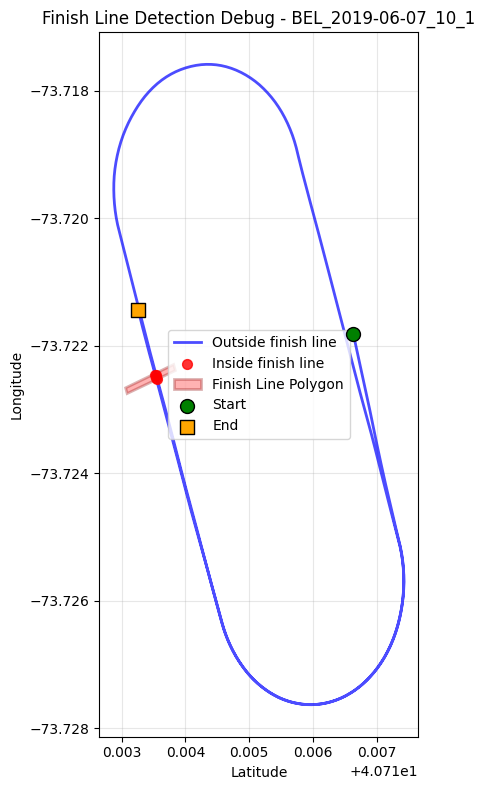

In [9]:
def debug_finish_line_detection(df, horse_pk):
    """
    Debug finish line detection for a specific horse
    """
    print(f"Debugging finish line detection for horse: {horse_pk}")
    print("=" * 60)
    
    # Get horse data
    horse_data = df.filter(pl.col("horse_pk") == horse_pk).sort("trakus_index")
    
    if horse_data.shape[0] == 0:
        print("No data found for this horse")
        return
    
    horse_df = horse_data.to_pandas()
    track_id = horse_df['track_id'].iloc[0]
    
    print(f"Track ID: {track_id}")
    print(f"Total tracking points: {len(horse_df)}")
    print(f"Trakus index range: {horse_df['trakus_index'].min()} - {horse_df['trakus_index'].max()}")
    
    # Get finish line coordinates
    finish_coords = {
        "AQU": [[40.671541,-73.831052],[40.671813,-73.832118],[40.671731,-73.832148],[40.671464,-73.831092]],
        "BEL": [[40.713841,-73.722387],[40.713086,-73.722747],[40.713062,-73.722658],[40.713815,-73.722292]],
        "SAR": [[43.071827,-73.770376],[43.072490,-73.770852],[43.072438,-73.770989],[43.071777,-73.770502]]
    }
    
    if track_id not in finish_coords:
        print(f"No finish line coordinates available for track: {track_id}")
        return
    
    # Test point-in-polygon for all points
    polygon_coords = finish_coords[track_id]
    
    def point_in_polygon_debug(lat, lon, polygon_coords):
        """Debug version with detailed output"""
        x, y = lat, lon
        n = len(polygon_coords)
        inside = False
        
        p1x, p1y = polygon_coords[0]
        for i in range(1, n + 1):
            p2x, p2y = polygon_coords[i % n]
            if y > min(p1y, p2y):
                if y <= max(p1y, p2y):
                    if x <= max(p1x, p2x):
                        if p1y != p2y:
                            xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                        if p1x == p2x or x <= xinters:
                            inside = not inside
            p1x, p1y = p2x, p2y
        
        return inside
    
    # Check each point
    inside_finish = []
    for _, row in horse_df.iterrows():
        is_inside = point_in_polygon_debug(row['latitude'], row['longitude'], polygon_coords)
        inside_finish.append(is_inside)
    
    horse_df['inside_finish'] = inside_finish
    
    # Find points inside finish line
    finish_points = horse_df[horse_df['inside_finish'] == True]
    
    print(f"\nPoints inside finish line polygon: {len(finish_points)}")
    
    if len(finish_points) > 0:
        print("\nFirst 5 points inside finish line:")
        print(finish_points[['trakus_index', 'latitude', 'longitude']].head())
        print(f"\nFirst trakus_index inside finish: {finish_points['trakus_index'].iloc[0]}")
        print(f"Last trakus_index inside finish: {finish_points['trakus_index'].iloc[-1]}")
    else:
        print("No points found inside finish line polygon!")
        print("\nLast 10 points (potential finish area):")
        print(horse_df[['trakus_index', 'latitude', 'longitude']].tail(10))
        
        # Check distance to finish line center
        finish_center_lat = sum([p[0] for p in polygon_coords]) / len(polygon_coords)
        finish_center_lon = sum([p[1] for p in polygon_coords]) / len(polygon_coords)
        
        print(f"\nFinish line center: ({finish_center_lat:.6f}, {finish_center_lon:.6f})")
        
        # Calculate distances to finish center for last few points
        from math import sqrt
        
        print("\nDistance to finish center for last 10 points:")
        for _, row in horse_df.tail(10).iterrows():
            dist = sqrt((row['latitude'] - finish_center_lat)**2 + (row['longitude'] - finish_center_lon)**2)
            print(f"Trakus {row['trakus_index']}: ({row['latitude']:.6f}, {row['longitude']:.6f}) - Distance: {dist:.8f}")
    
    # Test the long furlong threshold logic
    total_obs = len(horse_df)
    threshold = total_obs - 200
    print(f"\nLong furlong threshold: {threshold} (total obs: {total_obs})")
    
    if len(finish_points) > 0:
        valid_finish_points = finish_points[finish_points['trakus_index'] > threshold]
        print(f"Valid finish points after threshold: {len(valid_finish_points)}")
        
        if len(valid_finish_points) > 0:
            final_trakus = valid_finish_points['trakus_index'].iloc[0]
            print(f"Final finish trakus_index: {final_trakus}")
            
            # Check how many points would be removed
            points_after_finish = len(horse_df[horse_df['trakus_index'] > final_trakus])
            print(f"Points that should be removed: {points_after_finish}")
            print(f"Percentage to remove: {points_after_finish/total_obs*100:.2f}%")
        else:
            print("No valid finish points after applying threshold!")
    
    return horse_df

def visualize_finish_line_detection(df, horse_pk):
    """
    Visualize the finish line detection process
    """
    import matplotlib.pyplot as plt
    
    horse_data = df.filter(pl.col("horse_pk") == horse_pk).sort("trakus_index")
    horse_df = horse_data.to_pandas()
    track_id = horse_df['track_id'].iloc[0]
    
    # Get finish line coordinates
    finish_coords = {
        "AQU": [[40.671541,-73.831052],[40.671813,-73.832118],[40.671731,-73.832148],[40.671464,-73.831092]],
        "BEL": [[40.713841,-73.722387],[40.713086,-73.722747],[40.713062,-73.722658],[40.713815,-73.722292]],
        "SAR": [[43.071827,-73.770376],[43.072490,-73.770852],[43.072438,-73.770989],[43.071777,-73.770502]]
    }
    
    polygon_coords = finish_coords[track_id]
    
    # Test each point
    def point_in_polygon(lat, lon, polygon_coords):
        x, y = lat, lon
        n = len(polygon_coords)
        inside = False
        p1x, p1y = polygon_coords[0]
        for i in range(1, n + 1):
            p2x, p2y = polygon_coords[i % n]
            if y > min(p1y, p2y):
                if y <= max(p1y, p2y):
                    if x <= max(p1x, p2x):
                        if p1y != p2y:
                            xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                        if p1x == p2x or x <= xinters:
                            inside = not inside
            p1x, p1y = p2x, p2y
        return inside
    
    # Check all points
    inside_finish = [point_in_polygon(row['latitude'], row['longitude'], polygon_coords) 
                     for _, row in horse_df.iterrows()]
    
    # Create visualization
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Plot trajectory with different colors for inside/outside finish line
    outside_points = horse_df[~np.array(inside_finish)]
    inside_points = horse_df[np.array(inside_finish)]
    
    if len(outside_points) > 0:
        ax.plot(outside_points['latitude'], outside_points['longitude'], 
               'b-', alpha=0.7, linewidth=2, label='Outside finish line')
    
    if len(inside_points) > 0:
        ax.scatter(inside_points['latitude'], inside_points['longitude'], 
                  c='red', s=50, alpha=0.8, label='Inside finish line', zorder=5)
    
    # Plot finish line polygon
    from matplotlib.patches import Polygon as MplPolygon
    finish_polygon = MplPolygon(polygon_coords, alpha=0.3, facecolor='red', 
                               edgecolor='darkred', linewidth=2, label='Finish Line Polygon')
    ax.add_patch(finish_polygon)
    
    # Mark start and end
    ax.scatter(horse_df['latitude'].iloc[0], horse_df['longitude'].iloc[0], 
              c='green', s=100, marker='o', label='Start', zorder=6, edgecolors='black')
    ax.scatter(horse_df['latitude'].iloc[-1], horse_df['longitude'].iloc[-1], 
              c='orange', s=100, marker='s', label='End', zorder=6, edgecolors='black')
    
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')
    ax.set_title(f'Finish Line Detection Debug - {horse_pk}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    return len(inside_points)

# pick random horse_pk for testing


# Usage:
debug_info = debug_finish_line_detection(df, "BEL_2019-06-07_10_1")
inside_count = visualize_finish_line_detection(df, "BEL_2019-06-07_10_1")

Debug info for AQU_2019-01-01_1_3:
  Total points: 316
  Points inside finish polygon: 3
  Finish trakus_index: 291
  Points to be removed: 25 (7.9%)
Debug info for AQU_2019-01-01_1_3:
  Total points: 316
  Points inside finish polygon: 3
  Finish trakus_index: 291
  Points to be removed: 25 (7.9%)


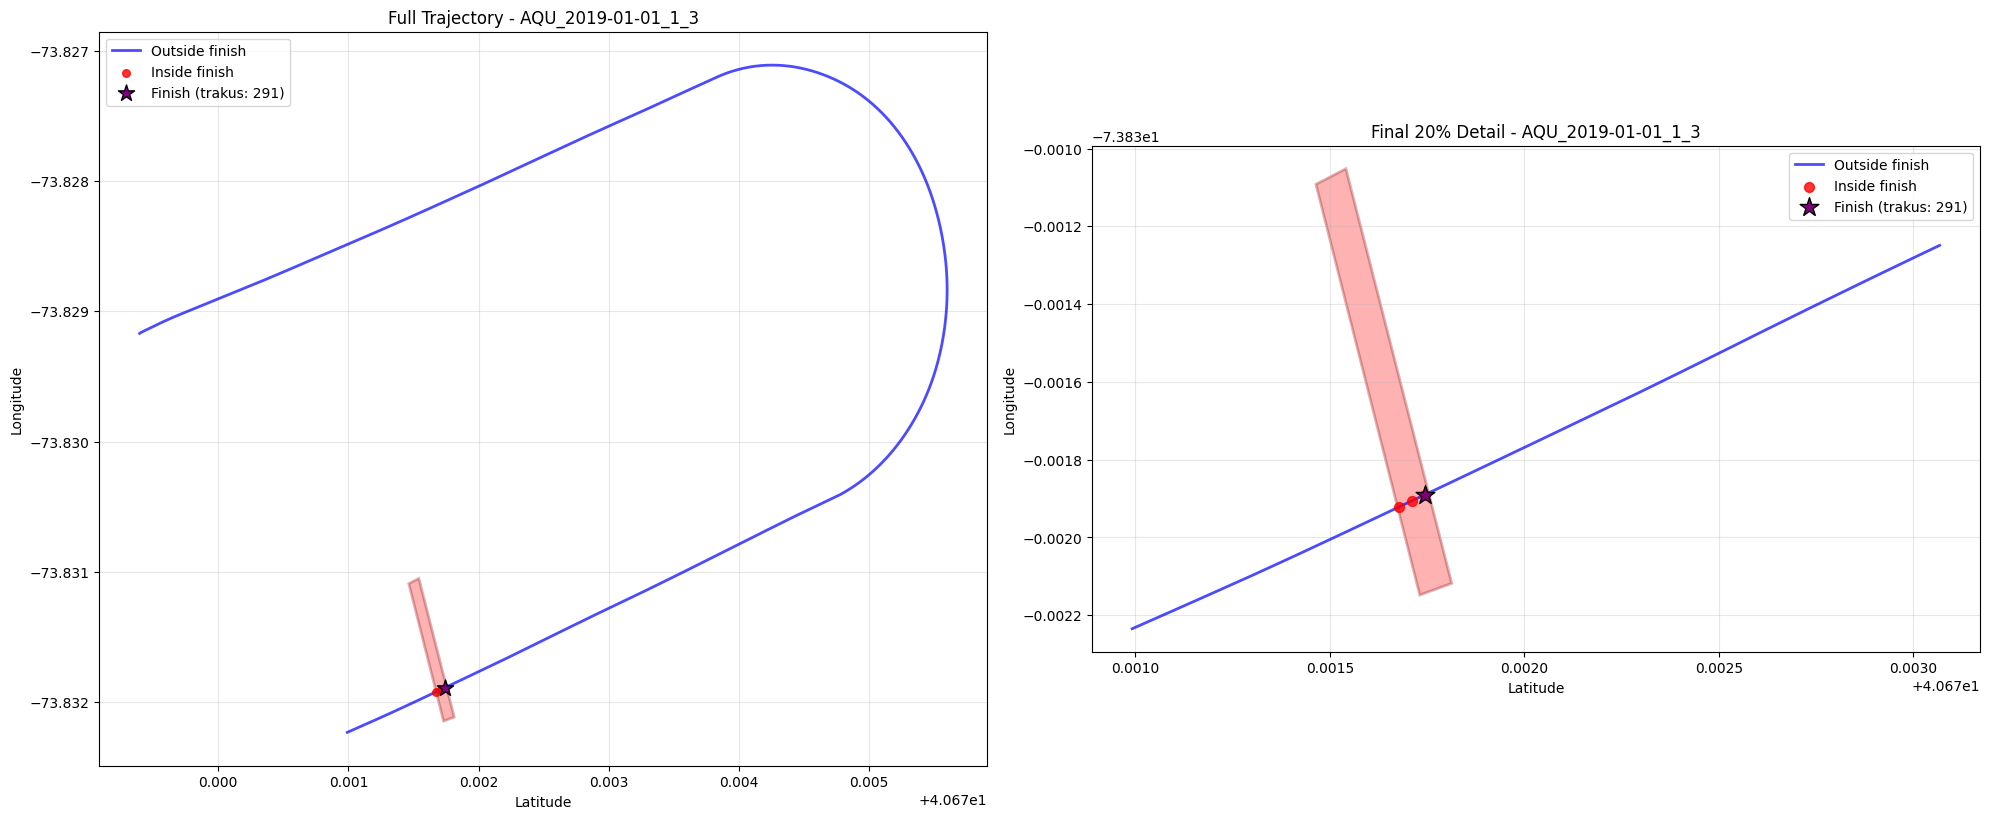

In [ ]:

def point_in_polygon_vectorized(latitudes, longitudes, polygon_coords):
    """
    Vectorized point-in-polygon test for better performance and consistency.
    Uses the ray casting algorithm.
    """
    points = np.column_stack((latitudes, longitudes))
    polygon = np.array(polygon_coords)
    
    n_points = len(points)
    n_vertices = len(polygon)
    inside = np.zeros(n_points, dtype=bool)
    
    for i in range(n_points):
        x, y = points[i]
        
        # Ray casting algorithm
        j = n_vertices - 1
        for k in range(n_vertices):
            xi, yi = polygon[k]
            xj, yj = polygon[j]
            
            if ((yi > y) != (yj > y)) and (x < (xj - xi) * (y - yi) / (yj - yi) + xi):
                inside[i] = not inside[i]
            j = k
    
    return inside

def find_finish_crossing_robust(df, horse_pk, debug=False):
    """
    Robust finish line detection that handles edge cases and ensures complete truncation.
    
    Args:
        df: Polars DataFrame with horse tracking data
        horse_pk: Horse identifier
        debug: Whether to print debug information
    
    Returns:
        tuple: (finish_trakus_index, truncated_df) or (None, original_df)
    """
    # Get horse data
    horse_data = df.filter(pl.col("horse_pk") == horse_pk).sort("trakus_index")
    
    if horse_data.shape[0] == 0:
        if debug:
            print(f"No data found for horse: {horse_pk}")
        return None, df
    
    horse_df = horse_data.to_pandas()
    track_id = horse_df['track_id'].iloc[0]
    
    # Finish line coordinates
    finish_coords = {
        "AQU": [[40.671541,-73.831052],[40.671813,-73.832118],[40.671731,-73.832148],[40.671464,-73.831092]],
        "BEL": [[40.713841,-73.722387],[40.713086,-73.722747],[40.713062,-73.722658],[40.713815,-73.722292]],
        "SAR": [[43.071827,-73.770376],[43.072490,-73.770852],[43.072438,-73.770989],[43.071777,-73.770502]]
    }
    
    if track_id not in finish_coords:
        if debug:
            print(f"No finish line coordinates for track: {track_id}")
        return None, df
    
    polygon_coords = finish_coords[track_id]
    
    # Vectorized point-in-polygon test
    inside_finish = point_in_polygon_vectorized(
        horse_df['latitude'].values, 
        horse_df['longitude'].values, 
        polygon_coords
    )
    
    horse_df['inside_finish'] = inside_finish
    
    # Find finish line crossings with improved logic
    total_points = len(horse_df)
    
    # Strategy 1: Look for the first entry into finish polygon after 80% of race
    # This handles cases where horses might briefly clip the finish area early
    late_race_threshold = int(total_points * 0.8)
    late_race_df = horse_df.iloc[late_race_threshold:]
    late_race_inside = late_race_df['inside_finish'].values
    
    finish_trakus = None
    
    if np.any(late_race_inside):
        # Find first point inside finish line in late race
        first_inside_idx = np.where(late_race_inside)[0][0]
        finish_trakus = late_race_df.iloc[first_inside_idx]['trakus_index']
        
    # Strategy 2: If no late race detection, use distance-based fallback
    if finish_trakus is None:
        # Calculate finish line center
        finish_center_lat = np.mean([p[0] for p in polygon_coords])
        finish_center_lon = np.mean([p[1] for p in polygon_coords])
        
        # Find closest approach in final 10% of race
        final_portion = horse_df.iloc[int(total_points * 0.9):]
        distances = np.sqrt(
            (final_portion['latitude'] - finish_center_lat)**2 + 
            (final_portion['longitude'] - finish_center_lon)**2
        )
        
        # Use point of closest approach as finish
        closest_idx = np.argmin(distances)
        finish_trakus = final_portion.iloc[closest_idx]['trakus_index']
        
        if debug:
            print(f"Using distance-based fallback. Closest approach at trakus_index: {finish_trakus}")
    
    # Strategy 3: Enhanced validation - ensure we don't truncate too early
    if finish_trakus is not None:
        finish_position = horse_df[horse_df['trakus_index'] == finish_trakus].index[0]
        points_to_remove = total_points - finish_position - 1
        removal_percentage = points_to_remove / total_points
        
        # If we're removing more than 15% of points, be more conservative
        if removal_percentage > 0.15:
            # Look for a later crossing or use a more conservative cutoff
            conservative_threshold = int(total_points * 0.95)
            if finish_position < conservative_threshold:
                # Find the latest point inside finish line or use 95% point
                finish_indices = horse_df[horse_df['inside_finish']]['trakus_index'].values
                if len(finish_indices) > 0:
                    finish_trakus = finish_indices[-1]  # Use last point inside
                else:
                    finish_trakus = horse_df.iloc[conservative_threshold]['trakus_index']
                
                if debug:
                    print(f"Applied conservative truncation at trakus_index: {finish_trakus}")
    
    if debug:
        inside_count = np.sum(inside_finish)
        print(f"Debug info for {horse_pk}:")
        print(f"  Total points: {total_points}")
        print(f"  Points inside finish polygon: {inside_count}")
        print(f"  Finish trakus_index: {finish_trakus}")
        if finish_trakus:
            points_after = len(horse_df[horse_df['trakus_index'] > finish_trakus])
            print(f"  Points to be removed: {points_after} ({points_after/total_points*100:.1f}%)")
    
    # Apply truncation
    if finish_trakus is not None:
        # Create truncated dataset
        truncated_df = df.filter(
            (pl.col("horse_pk") != horse_pk) | 
            (pl.col("trakus_index") <= finish_trakus)
        )
        return finish_trakus, truncated_df
    
    return None, df

def batch_process_finish_detection(df, debug_sample=None):
    """
    Process finish line detection for all horses in the dataset.
    
    Args:
        df: Polars DataFrame with all horse data
        debug_sample: Number of horses to debug (None for no debug output)
    
    Returns:
        Polars DataFrame with finish line truncation applied
    """
    horse_pks = df.select("horse_pk").unique().to_pandas()['horse_pk'].tolist()
    
    print(f"Processing finish line detection for {len(horse_pks)} horses...")
    
    current_df = df.clone()
    truncation_stats = []
    
    for i, horse_pk in enumerate(horse_pks):
        debug_this = debug_sample and i < debug_sample
        
        finish_trakus, current_df = find_finish_crossing_robust(
            current_df, horse_pk, debug=debug_this
        )
        
        if finish_trakus:
            truncation_stats.append({
                'horse_pk': horse_pk,
                'finish_trakus': finish_trakus,
                'truncated': True
            })
        else:
            truncation_stats.append({
                'horse_pk': horse_pk,
                'finish_trakus': None,
                'truncated': False
            })
        
        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1}/{len(horse_pks)} horses")
    
    # Summary statistics
    truncated_count = sum(1 for stat in truncation_stats if stat['truncated'])
    print(f"\nTruncation Summary:")
    print(f"  Successfully truncated: {truncated_count}/{len(horse_pks)} horses")
    print(f"  Success rate: {truncated_count/len(horse_pks)*100:.1f}%")
    
    return current_df, truncation_stats

def visualize_finish_detection_improved(df, horse_pk):
    """
    Enhanced visualization of finish line detection with better debugging info.
    """
    horse_data = df.filter(pl.col("horse_pk") == horse_pk).sort("trakus_index")
    horse_df = horse_data.to_pandas()
    track_id = horse_df['track_id'].iloc[0]
    
    finish_coords = {
        "AQU": [[40.671541,-73.831052],[40.671813,-73.832118],[40.671731,-73.832148],[40.671464,-73.831092]],
        "BEL": [[40.713841,-73.722387],[40.713086,-73.722747],[40.713062,-73.722658],[40.713815,-73.722292]],
        "SAR": [[43.071827,-73.770376],[43.072490,-73.770852],[43.072438,-73.770989],[43.071777,-73.770502]]
    }
    
    polygon_coords = finish_coords[track_id]
    
    # Test finish detection
    inside_finish = point_in_polygon_vectorized(
        horse_df['latitude'].values, 
        horse_df['longitude'].values, 
        polygon_coords
    )
    
    # Find finish using our robust method
    finish_trakus, _ = find_finish_crossing_robust(df, horse_pk, debug=True)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Full trajectory
    outside_mask = ~inside_finish
    inside_mask = inside_finish
    
    if np.any(outside_mask):
        ax1.plot(horse_df.loc[outside_mask, 'latitude'], 
                horse_df.loc[outside_mask, 'longitude'], 
                'b-', alpha=0.7, linewidth=2, label='Outside finish')
    
    if np.any(inside_mask):
        ax1.scatter(horse_df.loc[inside_mask, 'latitude'], 
                   horse_df.loc[inside_mask, 'longitude'], 
                   c='red', s=30, alpha=0.8, label='Inside finish', zorder=5)
    
    # Add finish polygon
    finish_polygon = MplPolygon(polygon_coords, alpha=0.3, facecolor='red', 
                               edgecolor='darkred', linewidth=2)
    ax1.add_patch(finish_polygon)
    
    # Mark finish point if found
    if finish_trakus:
        finish_point = horse_df[horse_df['trakus_index'] == finish_trakus]
        if len(finish_point) > 0:
            ax1.scatter(finish_point['latitude'], finish_point['longitude'], 
                       c='purple', s=150, marker='*', 
                       label=f'Finish (trakus: {finish_trakus})', 
                       zorder=6, edgecolors='black')
    
    ax1.set_xlabel('Latitude')
    ax1.set_ylabel('Longitude')
    ax1.set_title(f'Full Trajectory - {horse_pk}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Final portion detail
    final_portion = horse_df.iloc[int(len(horse_df) * 0.8):]
    final_outside = ~inside_finish[int(len(horse_df) * 0.8):]
    final_inside = inside_finish[int(len(horse_df) * 0.8):]
    
    if np.any(final_outside):
        ax2.plot(final_portion.loc[final_outside, 'latitude'], 
                final_portion.loc[final_outside, 'longitude'], 
                'b-', alpha=0.7, linewidth=2, label='Outside finish')
    
    if np.any(final_inside):
        ax2.scatter(final_portion.loc[final_inside, 'latitude'], 
                   final_portion.loc[final_inside, 'longitude'], 
                   c='red', s=50, alpha=0.8, label='Inside finish', zorder=5)
    
    # Add finish polygon to detail view
    finish_polygon2 = MplPolygon(polygon_coords, alpha=0.3, facecolor='red', 
                                edgecolor='darkred', linewidth=2)
    ax2.add_patch(finish_polygon2)
    
    # Mark finish point in detail view
    if finish_trakus:
        finish_point = horse_df[horse_df['trakus_index'] == finish_trakus]
        if len(finish_point) > 0:
            ax2.scatter(finish_point['latitude'], finish_point['longitude'], 
                       c='purple', s=200, marker='*', 
                       label=f'Finish (trakus: {finish_trakus})', 
                       zorder=6, edgecolors='black')
    
    ax2.set_xlabel('Latitude')
    ax2.set_ylabel('Longitude')
    ax2.set_title(f'Final 20% Detail - {horse_pk}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    return finish_trakus

# Example usage:
# Process single horse with debugging
finish_trakus, truncated_df = find_finish_crossing_robust(df, "AQU_2019-01-01_1_3", debug=True)

# Visualize the detection
detected_finish = visualize_finish_detection_improved(df, "AQU_2019-01-01_1_3")


In [ ]:
# check for the pk 

df.filter(pl.col("horse_pk") == "AQU_2019-01-01_1_3").sort(by="trakus_index", descending=True).head(30)

track_id,race_date,race_number,program_number,trakus_index,latitude,longitude,distance_id,course_type,track_condition,run_up_distance,race_type,purse,post_time,weight_carried,jockey,odds,position_at_finish,horse_pk,rid,horse_id,horse_name,win,time_seconds,prev_latitude,prev_longitude,prev_time_seconds,distance_meters,speed_kmh,race_progress,race_stage
str,str,i64,str,i64,f64,f64,i64,str,str,i64,str,f64,i64,i64,str,i64,i64,str,str,str,str,i8,f64,f64,f64,f64,f64,f64,f64,str
"""AQU""","""2019-01-01""",1,"""3""",1,40.669396,-73.829169,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,0.25,null,null,null,0.0,null,0.003165,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",2,40.6694,-73.829167,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,0.5,40.669396,-73.829169,0.25,0.000488,0.007022,0.009494,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",3,40.669405,-73.829163,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,0.75,40.6694,-73.829167,0.5,0.000629,0.009053,0.018987,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",4,40.669411,-73.82916,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,1.0,40.669405,-73.829163,0.75,0.000754,0.010854,0.031646,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",5,40.669423,-73.829154,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,1.25,40.669411,-73.82916,1.0,0.001475,0.021242,0.047468,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",6,40.669438,-73.829146,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,1.5,40.669423,-73.829154,1.25,0.001762,0.025376,0.066456,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",7,40.669456,-73.829138,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,1.75,40.669438,-73.829146,1.5,0.002041,0.029385,0.088608,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",8,40.669475,-73.829128,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,2.0,40.669456,-73.829138,1.75,0.002276,0.032777,0.113924,"""stage1"""
"""AQU""","""2019-01-01""",1,"""3""",9,40.669497,-73.829117,650,"""Dirt""","""MY """,36,"""AOC""",80000.0,1220,118,"""Jose Lezcano""",180,4,"""AQU_2019-01-01_1_3""","""AQU_2019-01-01_1""","""3""","""Friend of Liberty""",0,2.25,40.669475,-73.829128,2.0,0.002658,0.038281,0.142405,"""stage1"""
